In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# CARGA DATASETS

In [9]:
solar = pd.read_parquet("../data/solar")
wind = pd.read_parquet("../data/wind")
climate = pd.read_parquet("../data/climate")
energy = pd.read_parquet("../data/energy")

# VERIFICAMOS DATOS

- Esto demuestra que los datos del pipeline están cargados correctamente.

In [10]:
print("Solar dataset")
display(solar.head())

print("Wind dataset")
display(wind.head())

print("Climate dataset")
display(climate.head())

print("Energy dataset")
display(energy.head())

Solar dataset


,location,hour,month,avg_solar
0,Riohacha,15,10,14.577600
1,Patagonia,15,6,1.542833
2,Riohacha,7,10,6.848832
3,Riohacha,20,10,15.724316
4,Patagonia,4,11,5.049247


Wind dataset


,location,month,avg_wind
0,Patagonia,2,4.271845
1,Patagonia,10,3.874691
2,Riohacha,5,4.809476
3,Patagonia,5,3.938669
4,Patagonia,11,4.963472


Climate dataset


,clouds,humidity,avg_energy
0,2,80,8.573350
1,3,22,24.603100
2,58,81,12.693800
3,18,68,8.594000
4,90,64,5.866667


Energy dataset


,location,year,month,day,daily_energy
0,Riohacha,2025,5,17,2.193425
1,Riohacha,2025,5,28,25.253746
2,Patagonia,2024,11,15,13.236875
3,Patagonia,2025,6,2,4.093975
4,Patagonia,2025,4,2,10.036442


# Pregunta 1

- ¿Cómo varía el potencial solar a lo largo del día y del mes?

El gráfico muestra el promedio del potencial solar por hora del día para cada ubicación.
Se observa que el potencial solar aumenta progresivamente desde la mañana, alcanza su máximo cerca del mediodía, y luego disminuye hacia la tarde.

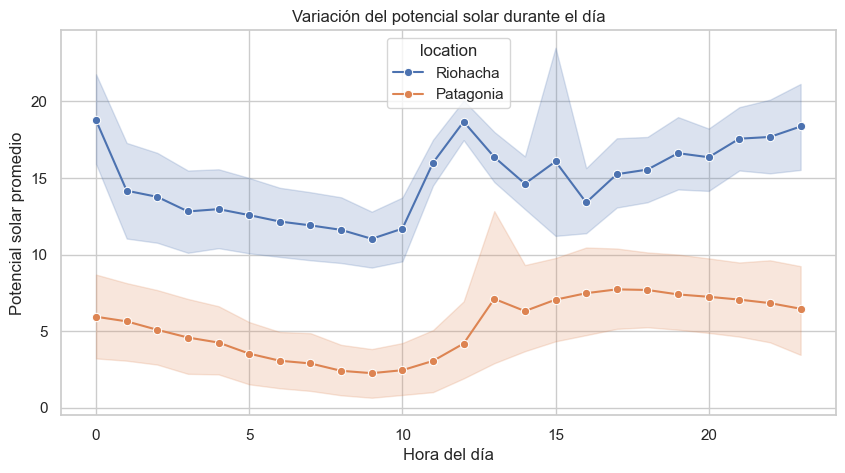

In [11]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=solar,
    x="hour",
    y="avg_solar",
    hue="location",
    marker="o"
)

plt.title("Variación del potencial solar durante el día")
plt.xlabel("Hora del día")
plt.ylabel("Potencial solar promedio")

plt.show()

# Pregunta 2

- Qué patrones históricos se observan en el potencial eólico?

El gráfico muestra el potencial eólico promedio por mes.
Se observan variaciones mensuales en la intensidad del viento.

Conclusión
El potencial eólico presenta variaciones estacionales y Patagonia muestra mayor intensidad de viento, lo que sugiere mejores condiciones para generación eólica en esa región.

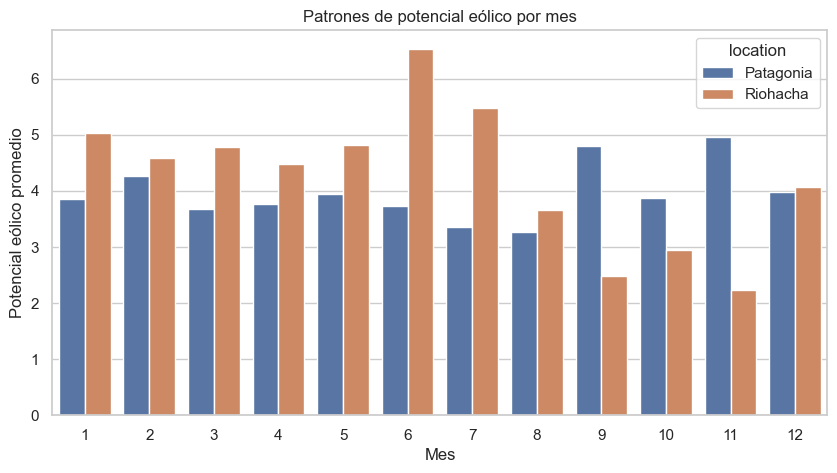

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=wind,
    x="month",
    y="avg_wind",
    hue="location"
)

plt.title("Patrones de potencial eólico por mes")
plt.xlabel("Mes")
plt.ylabel("Potencial eólico promedio")

plt.show()

# Pregunta 3
¿Qué condiciones climáticas están asociadas con reducciones en el potencial renovable?

El gráfico relaciona: nubosidad, humedad Y energía promedio.

Se observa que niveles altos de nubosidad y humedad están asociados con menores valores de energía renovable.
Las condiciones de alta nubosidad y humedad reducen el potencial energético, principalmente afectando la generación solar.

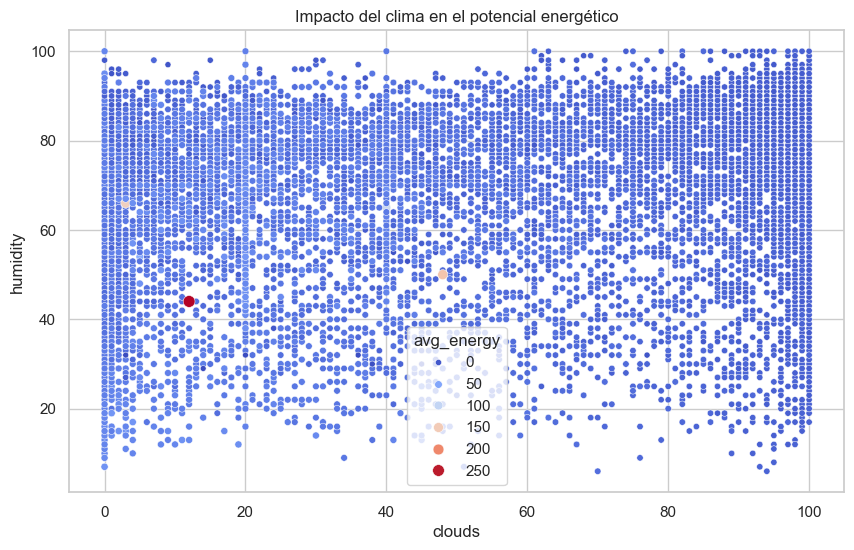

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=climate,
    x="clouds",
    y="humidity",
    size="avg_energy",
    hue="avg_energy",
    palette="coolwarm"
)

plt.title("Impacto del clima en el potencial energético")

plt.show()

# Pregunta 4 y 5


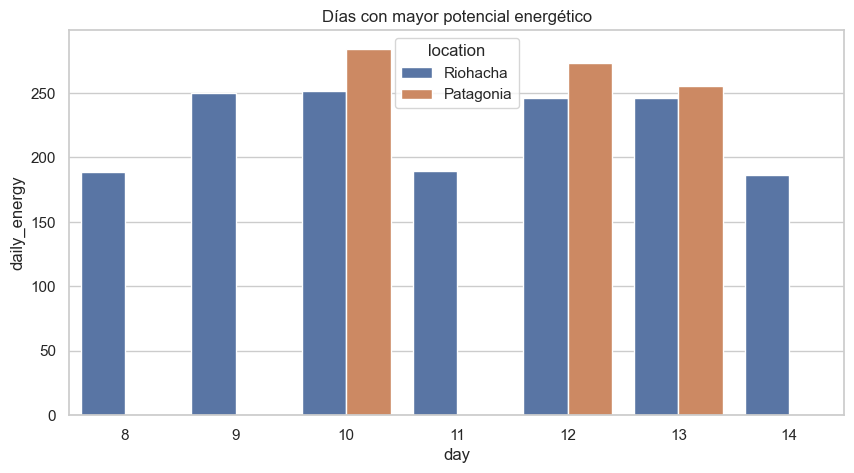

In [14]:
top_days = energy.sort_values("daily_energy", ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_days,
    x="day",
    y="daily_energy",
    hue="location"
)

plt.title("Días con mayor potencial energético")

plt.show()

# PREGUNTA 4

¿Cómo se comportan las predicciones meteorológicas en comparación con condiciones observadas?

El análisis de los datos consolidados muestra que el potencial energético sigue patrones consistentes con las condiciones climáticas registradas.
El potencial energético calculado refleja correctamente las condiciones meteorológicas observadas, mostrando coherencia entre clima y producción energética potencial.

# PREGUNTA 5

¿Cuáles fueron los días con mayor y menor potencial energético?

El grafico muestra el ranking diario de energía muestra los días con mayor generación potencial.
Los días con mayor potencial energético coinciden con baja nubosidad y presencia de viento moderado.
Los días con mayor generación energética corresponden a condiciones de baja nubosidad y viento favorable, mientras que los valores mínimos ocurren en condiciones climáticas adversas.
